In [1]:
import matplotlib.gridspec as gridspec

import sys
sys.path.append('../utils')
from utils_visualization import *

In [2]:
linestyles = [(0,(3,1,1,1)),'-',(0,(5,2,5,2))]

def plot_fluxonium_transitions(ax,matrix, energies,xlim,qls = [0,1,2],ylim = (2e-3,0.8) ):
    k = len(energies)  # Assuming matrix is k x k and energies is a list of length k
                        
    label_positions = []


    for i in qls:
        for j in range(k): 
            if j >i:
                freq_ij = np.abs(energies[i] - energies[j])  # Frequency of the transition
                element_ij = abs(matrix[i, j])  # Matrix element
                
                if element_ij > 1e-3:
                    ax.plot([freq_ij, freq_ij], [0, element_ij], marker='o', color='grey', markersize=4)

                if element_ij >= 1e-3:
                    x_loc = freq_ij  #- 0.1
                    y_loc = element_ij+0.003
                    text_pos = (x_loc, y_loc)


                    if x_loc < xlim[-1] and x_loc > xlim[0] and y_loc > ylim[0] and y_loc <ylim[-1]:
                        ax.text(*(x_loc,y_loc), rf'{i}-{j}', size=9)
                        label_positions.append(text_pos)
                    else:
                        # print(f'omitted: {i}-{j}')
                        pass

    # ax.set_xlabel(r'transition frequency $\omega_{ij}$')
    ax.grid(which='major', linestyle=':', linewidth='0.5', color='black')
    ax.set_xlim(xlim)
    # ax.set_yscale('log')
    ax.set_ylim(ylim)

def plot_sweep_Er(ax,matrix, evals,Er_list,qls = [0,1,2],ylim=(-1,1),participating_transitions = None):
    colors = ['red','green','orange']
    num_evals =len(evals)

    if participating_transitions != None:
        for i in range(num_evals):
                for j in range(num_evals): 
                    if (i, j) not in participating_transitions and (j, i) not in participating_transitions:
                        matrix[i, j] = 0 

    for ql  in qls:
        color  = colors[ql]
        linestyle = linestyles[ql]
        shift_from_qubit_transition = []
        for Er in tqdm(Er_list, desc = "Er loop"):
            shifts = [get_shift_accurate(matrix[ql,ql2], evals[ql2], evals[ql], Er) for ql2 in range(num_evals)] 
            shift_from_qubit_transition.append(sum(shifts)/100)
        ax.plot(Er_list, shift_from_qubit_transition, label=rf'$\chi_{ql}$',color = color, linestyle = linestyle)

    ax.grid(which='major', linestyle=':', linewidth='0.5', color='black')
    ax.minorticks_on()
    ax.grid(which='minor', linestyle=':', linewidth='0.5', color='gray')
    ax.set_xlim(Er_list[0],Er_list[-1])
    ax.set_ylim(ylim[0],ylim[1])
    ax.set_xlabel(rf'$\omega_r$/ $2\pi$ (GHZ)')
    ax.set_yticklabels([f'{val:.0f}' for val in ax.get_yticks() *1000])
    ax.set_ylabel(r'$\chi$/ $2\pi$ (MHz)')

Er loop: 100%|██████████| 10000/10000 [00:00<00:00, 64134.95it/s]
 /tmp/ipykernel_625264/2509973518.py: 62

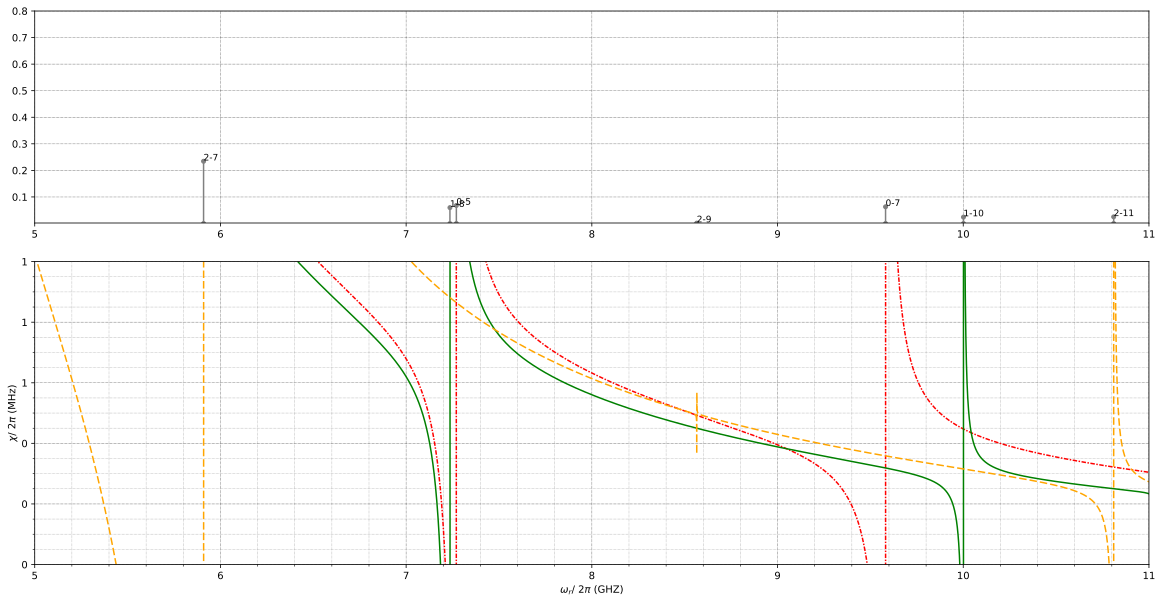

In [27]:
n_evals = 20

qbt = scqubits.Fluxonium(EJ = 4,EC = 4/6,EL = 4/20, cutoff = 110,flux = 0,truncated_dim=40)
eigenvals = qbt.eigenvals(n_evals)
elements =  qbt.matrixelement_table(operator = "n_operator",evals_count=n_evals)
Er_list = np.linspace(5,11,int(1e4))

fig = plt.figure(figsize=(20, 10)) 
gs = gridspec.GridSpec(2, 1, height_ratios=[0.7, 1], hspace=0.15)
plot_fluxonium_transitions(plt.subplot(gs[0]), elements, eigenvals,xlim = (Er_list[0],Er_list[-1]))
plot_sweep_Er(plt.subplot(gs[1]), elements,eigenvals,Er_list,qls = [0,1,2],ylim=(0,1e-3))

(<Figure size 640x480 with 1 Axes>,
 <Axes: xlabel='$\\varphi$', ylabel='Re $\\psi_j(\\varphi)$,  energy [GHz]'>)

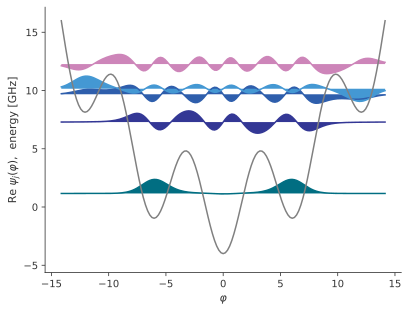

In [23]:
qbt.plot_wavefunction(which=[2,7,9,11,13])

Er loop: 100%|██████████| 10000/10000 [00:00<00:00, 26637.30it/s]
 /tmp/ipykernel_625264/2509973518.py: 62

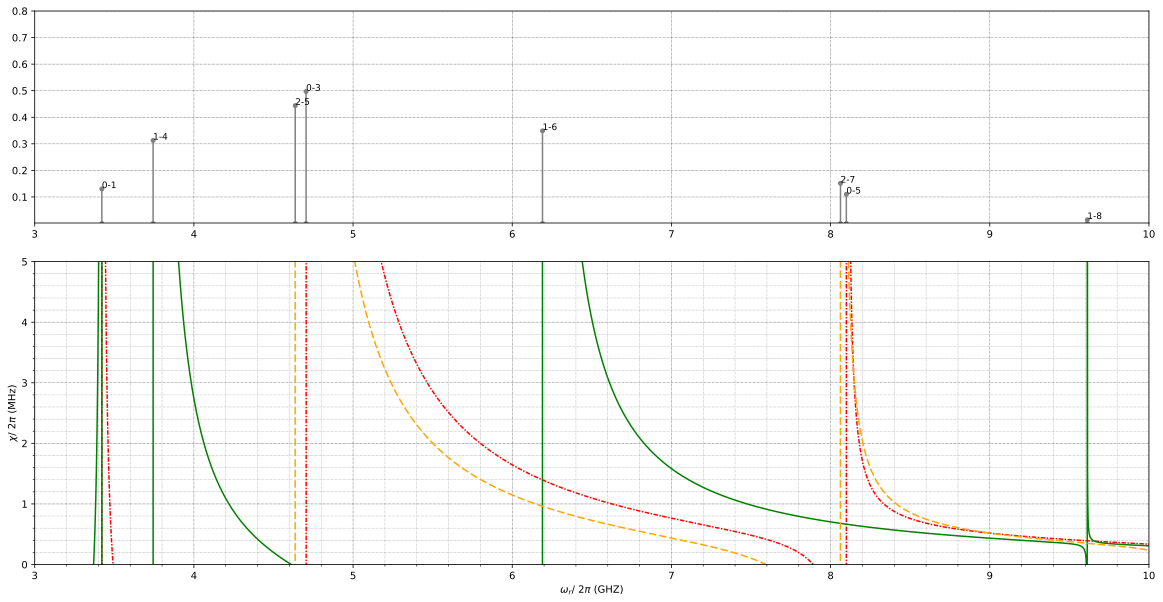

In [36]:
n_evals = 20

qbt = scqubits.Fluxonium(EJ = 4,EC = 4/3.8,EL = 4/21.1, cutoff = 110,flux = 0,truncated_dim=40)
eigenvals = qbt.eigenvals(n_evals)
elements =  qbt.matrixelement_table(operator = "n_operator",evals_count=n_evals)
Er_list = np.linspace(3,10,int(1e4))

fig = plt.figure(figsize=(20, 10)) 
gs = gridspec.GridSpec(2, 1, height_ratios=[0.7, 1], hspace=0.15)
plot_fluxonium_transitions(plt.subplot(gs[0]), elements, eigenvals,xlim = (Er_list[0],Er_list[-1]))
plot_sweep_Er(plt.subplot(gs[1]), elements,eigenvals,Er_list,qls = [0,1,2],ylim=(0,5e-3))

(<Figure size 640x480 with 1 Axes>,
 <Axes: xlabel='$\\varphi$', ylabel='Re $\\psi_j(\\varphi)$,  energy [GHz]'>)

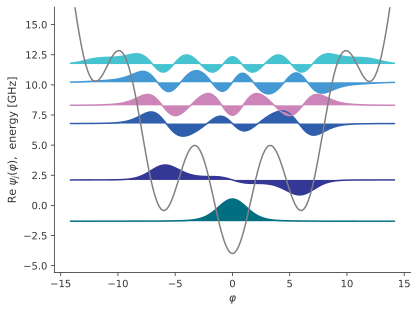

In [37]:
qbt.plot_wavefunction(which=[0,1, 5,7 ,6,8])

Er loop: 100%|██████████| 10000/10000 [00:00<00:00, 90918.64it/s]
 /tmp/ipykernel_644440/2509973518.py: 62

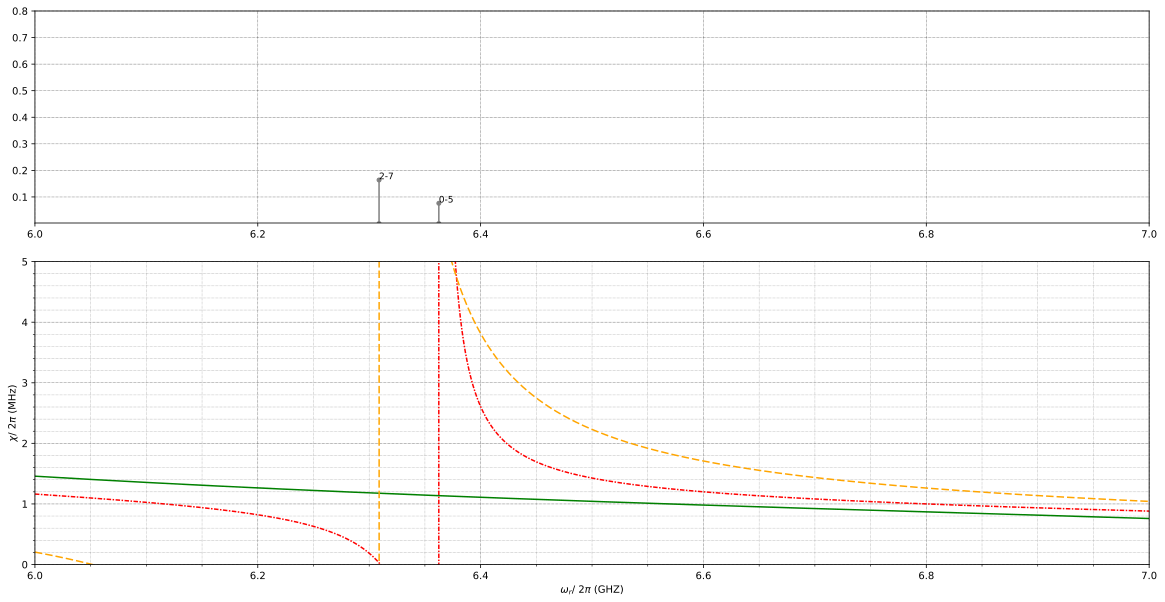

In [4]:
n_evals = 20

qbt = scqubits.Fluxonium(EJ = 4,EC = 4/5.9,EL = 4/29.2, cutoff = 110,flux = 0,truncated_dim=40)
eigenvals = qbt.eigenvals(n_evals)
elements =  qbt.matrixelement_table(operator = "n_operator",evals_count=n_evals)
Er_list = np.linspace(6,7,int(1e4))

fig = plt.figure(figsize=(20, 10)) 
gs = gridspec.GridSpec(2, 1, height_ratios=[0.7, 1], hspace=0.15)
plot_fluxonium_transitions(plt.subplot(gs[0]), elements, eigenvals,xlim = (Er_list[0],Er_list[-1]))
plot_sweep_Er(plt.subplot(gs[1]), elements,eigenvals,Er_list,qls = [0,1,2],ylim=(0,5e-3))

Er loop: 100%|██████████| 10000/10000 [00:00<00:00, 90099.33it/s]
 /tmp/ipykernel_644440/2509973518.py: 62

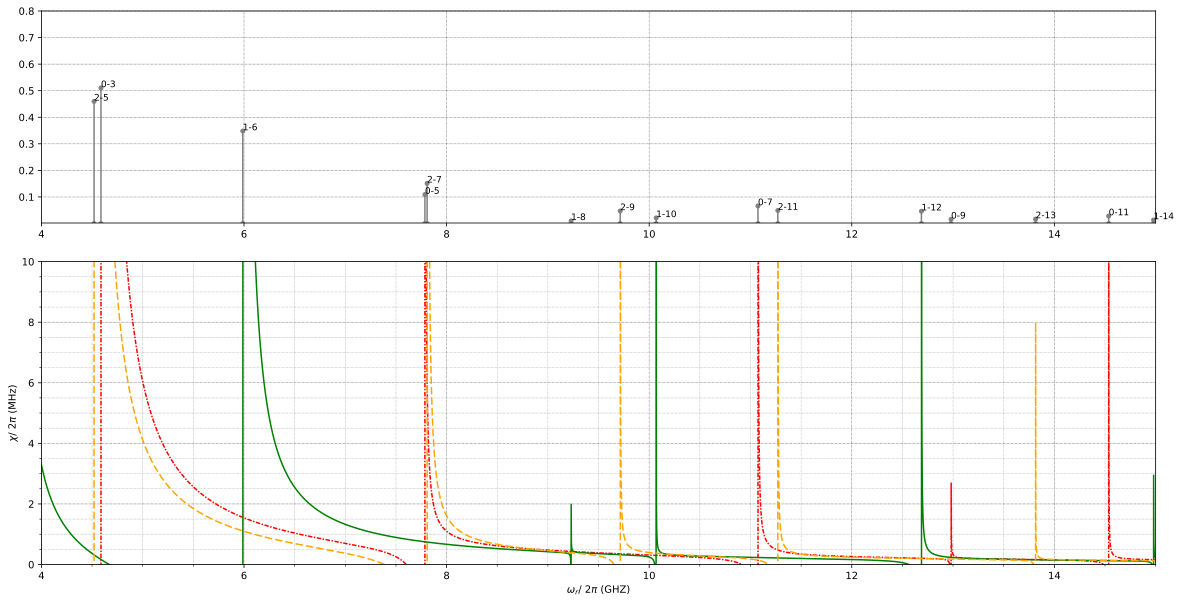

In [10]:
n_evals = 20

qbt = scqubits.Fluxonium(EJ = 4,EC = 4/4,EL = 4/22.5, cutoff = 110,flux = 0,truncated_dim=40)
eigenvals = qbt.eigenvals(n_evals)
elements =  qbt.matrixelement_table(operator = "n_operator",evals_count=n_evals)
Er_list = np.linspace(4,15,int(1e4))

fig = plt.figure(figsize=(20, 10)) 
gs = gridspec.GridSpec(2, 1, height_ratios=[0.7, 1], hspace=0.15)
plot_fluxonium_transitions(plt.subplot(gs[0]), elements, eigenvals,xlim = (Er_list[0],Er_list[-1]))
plot_sweep_Er(plt.subplot(gs[1]), elements,eigenvals,Er_list,qls = [0,1,2],ylim=(0,1e-2))